# Generation 2: Good Performance Results

This notebook analyzes the Generation 2 experiments that showed good counterfactual generation performance, specifically:
- **Baseline experiments**: Models trained with standard settings
- **Optimized XGBoost experiments**: Models with hyperparameter tuning

These experiments demonstrated higher validity and solved rates compared to SMOTE and weighted models.

------

In [28]:
# import
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [29]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [30]:
import os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

ROOT_DIR = Path(os.getenv("PROJECT_ROOT"))

RESULTS_CSV_PATH = ROOT_DIR / "analysis" / "gen_2_summary.csv"

print("root exists: ", ROOT_DIR.exists())
print("results is file: ", RESULTS_CSV_PATH.is_file())

root exists:  True
results is file:  True


In [31]:
df = pd.read_csv(RESULTS_CSV_PATH)

In [32]:
df

,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged,avg_nchanged_all,avg_gower_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
0,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,28,31.5%,100.0%,89.9%,2.50,2.35,0.19,0.2571,0.1194,0.0000,70.1,86.48,9.61,bmi: 100% | alcfreq: 36% | slprl: 29% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
1,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,56,23,41.1%,88.9%,89.3%,2.57,2.25,0.21,0.2042,0.1016,0.0000,71.9,144.35,16.04,bmi: 100% | alcfreq: 39% | dosprt: 39% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
2,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,30,33.3%,55.6%,88.9%,2.83,2.41,0.25,0.3452,0.1490,0.0010,74.5,9.40,1.04,bmi: 100% | dosprt: 43% | alcfreq: 40% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
3,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,50,21,42.0%,66.7%,94.0%,2.86,2.42,0.21,0.2807,0.1044,0.0021,77.9,9.55,1.06,bmi: 100% | alcfreq: 52% | dosprt: 48% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
4,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,8,9.0%,33.3%,88.8%,3.38,2.39,0.21,0.3461,0.1402,0.0826,65.7,140.61,15.62,bmi: 100% | alcfreq: 50% | slprl: 50% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
5,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,87,17,19.5%,55.6%,88.5%,3.24,2.37,0.21,0.3933,0.1828,0.0933,63.3,100.08,11.12,bmi: 100% | alcfreq: 59% | dosprt: 53% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
6,RandomForest_thres0.1_2026-05-11,genetic,RandomForest,True,10,1000,0.1,9,63,41,65.1%,100.0%,88.9%,2.37,2.25,0.18,0.0941,0.0264,0.0000,74.8,24.31,2.70,bmi: 100% | alcfreq: 32% | slprl: 27% | ...,predictors_vs_threshold/baseline/RandomForest_...
7,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,90,38,42.2%,100.0%,88.9%,2.32,2.20,0.21,0.1100,0.0333,0.0000,74.1,23.60,2.62,bmi: 100% | slprl: 39% | alcfreq: 32% | ...,predictors_vs_threshold/baseline/RandomForest_...
8,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,83,39,47.0%,100.0%,88.0%,2.38,2.31,0.19,0.1012,0.0280,0.0000,76.9,23.38,2.60,bmi: 100% | slprl: 36% | alcfreq: 33% | ...,predictors_vs_threshold/baseline/RandomForest_...
9,XGBoost_thres0.1_2026-05-11,genetic,XGBoost,True,10,1000,0.1,9,70,39,55.7%,77.8%,92.9%,2.15,2.06,0.17,0.0881,0.0225,0.0003,79.1,10.56,1.17,bmi: 100% | etfruit: 33% | slprl: 21% | ...,predictors_vs_threshold/baseline/XGBoost_thres...


## Filter for Baseline and Optimized Experiments

We'll filter the data to exclude SMOTE and weighted experiments, keeping only the good-performing ones.

In [33]:
# Filter to exclude SMOTE and weighted experiments
df_good = df[~df['csv_path'].str.contains('SMOTE|weighted', regex=True)].copy()
print(f"Total experiments: {len(df)}")
print(f"Baseline + Optimized experiments: {len(df_good)}")
df_good

Total experiments: 17
Baseline + Optimized experiments: 9


,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged,avg_nchanged_all,avg_gower_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
6,RandomForest_thres0.1_2026-05-11,genetic,RandomForest,True,10,1000,0.1,9,63,41,65.1%,100.0%,88.9%,2.37,2.25,0.18,0.0941,0.0264,0.0000,74.8,24.31,2.70,bmi: 100% | alcfreq: 32% | slprl: 27% | ...,predictors_vs_threshold/baseline/RandomForest_...
7,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,90,38,42.2%,100.0%,88.9%,2.32,2.20,0.21,0.1100,0.0333,0.0000,74.1,23.60,2.62,bmi: 100% | slprl: 39% | alcfreq: 32% | ...,predictors_vs_threshold/baseline/RandomForest_...
8,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,83,39,47.0%,100.0%,88.0%,2.38,2.31,0.19,0.1012,0.0280,0.0000,76.9,23.38,2.60,bmi: 100% | slprl: 36% | alcfreq: 33% | ...,predictors_vs_threshold/baseline/RandomForest_...
9,XGBoost_thres0.1_2026-05-11,genetic,XGBoost,True,10,1000,0.1,9,70,39,55.7%,77.8%,92.9%,2.15,2.06,0.17,0.0881,0.0225,0.0003,79.1,10.56,1.17,bmi: 100% | etfruit: 33% | slprl: 21% | ...,predictors_vs_threshold/baseline/XGBoost_thres...
10,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,39,43.3%,77.8%,88.9%,2.23,2.16,0.17,0.1023,0.0373,0.0007,71.9,9.90,1.10,bmi: 100% | etfruit: 28% | slprl: 26% | ...,predictors_vs_threshold/baseline/XGBoost_thres...
11,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,83,42,50.6%,100.0%,90.4%,2.45,2.29,0.20,0.0966,0.0257,0.0005,77.6,10.46,1.16,bmi: 100% | etfruit: 36% | alcfreq: 36% |...,predictors_vs_threshold/baseline/XGBoost_thres...
14,XGBoost_thres0.1_2026-05-11,genetic,XGBoost,True,10,1000,0.1,9,65,26,40.0%,88.9%,89.2%,2.50,2.22,0.18,0.0620,0.0137,0.0004,82.7,10.54,1.17,bmi: 100% | etfruit: 42% | alcfreq: 38% |...,predictors_vs_threshold/xgb_optimized/XGBoost_...
15,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,28,31.1%,88.9%,88.9%,2.50,2.27,0.17,0.0632,0.0133,0.0003,82.8,10.32,1.15,bmi: 100% | dosprt: 43% | etfruit: 36% | ...,predictors_vs_threshold/xgb_optimized/XGBoost_...
16,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,86,35,40.7%,100.0%,89.5%,2.23,2.14,0.17,0.0651,0.0112,0.0007,84.4,10.86,1.21,bmi: 100% | etfruit: 31% | eatveg: 29% | ...,predictors_vs_threshold/xgb_optimized/XGBoost_...


In [34]:
# Create a category column for better grouping
df_good['category'] = df_good['csv_path'].apply(
    lambda x: 'Baseline' if 'baseline' in x
              else 'Optimized XGBoost'
)

# Add model abbreviation
df_good['model_abbr'] = df_good['ml_model_type'].str[:3]

df_good[['experiment', 'category', 'ml_model_type', 'stopping_threshold', 'validity_%', 'solved_%']]

,experiment,category,ml_model_type,stopping_threshold,validity_%,solved_%
6,RandomForest_thres0.1_2026-05-11,Baseline,RandomForest,0.1,65.1%,100.0%
7,RandomForest_thres0.5_2026-05-11,Baseline,RandomForest,0.5,42.2%,100.0%
8,RandomForest_thres0.9_2026-05-11,Baseline,RandomForest,0.9,47.0%,100.0%
9,XGBoost_thres0.1_2026-05-11,Baseline,XGBoost,0.1,55.7%,77.8%
10,XGBoost_thres0.5_2026-05-11,Baseline,XGBoost,0.5,43.3%,77.8%
11,XGBoost_thres0.9_2026-05-11,Baseline,XGBoost,0.9,50.6%,100.0%
14,XGBoost_thres0.1_2026-05-11,Optimized XGBoost,XGBoost,0.1,40.0%,88.9%
15,XGBoost_thres0.5_2026-05-11,Optimized XGBoost,XGBoost,0.5,31.1%,88.9%
16,XGBoost_thres0.9_2026-05-11,Optimized XGBoost,XGBoost,0.9,40.7%,100.0%


## Summary Statistics

Key metrics for the good-performing experiments:

## Visualization

Comparing the good-performing experiments across different categories and thresholds.

In [35]:
# Prepare data for visualization
df_good["Validity_%"] = df_good["validity_%"].str.rstrip('%').astype(float)
df_good["Solved_%"] = df_good["solved_%"].str.rstrip('%').astype(float)
df_good["Actionable_%"] = df_good["actionable_%"].str.rstrip('%').astype(float)
df_good["Time"] = df_good["total_gen_time_sec"]

# Create labels
df_good["Category"] = df_good["category"]
df_good["Model"] = df_good["ml_model_type"]
df_good["Threshold"] = df_good["stopping_threshold"]

# Create combined Model_Config for separate lines
df_good["Model_Config"] = df_good.apply(
    lambda row: f"Baseline {row['Model']}" if row['Category'] == 'Baseline'
                else f"Optimized {row['Model']}",
    axis=1
)

# Add risk metrics for additional analysis
df_good["Gower"] = df_good["avg_gower_valid"]
df_good["Risk_Before"] = df_good["avg_risk_before"] * 100  # Convert to percentage
df_good["Risk_After"] = df_good["avg_risk_after"] * 100    # Convert to percentage
df_good["Risk_Reduction_%"] = df_good["risk_reduction_%"]

# Display summary
df_good[["Category", "Model", "Model_Config", "Threshold", "Validity_%", "Solved_%", "Time"]].sort_values(['Category', 'Model', 'Threshold'])


,Category,Model,Model_Config,Threshold,Validity_%,Solved_%,Time
6,Baseline,RandomForest,Baseline RandomForest,0.1,65.1,100.0,24.31
7,Baseline,RandomForest,Baseline RandomForest,0.5,42.2,100.0,23.60
8,Baseline,RandomForest,Baseline RandomForest,0.9,47.0,100.0,23.38
9,Baseline,XGBoost,Baseline XGBoost,0.1,55.7,77.8,10.56
10,Baseline,XGBoost,Baseline XGBoost,0.5,43.3,77.8,9.90
11,Baseline,XGBoost,Baseline XGBoost,0.9,50.6,100.0,10.46
14,Optimized XGBoost,XGBoost,Optimized XGBoost,0.1,40.0,88.9,10.54
15,Optimized XGBoost,XGBoost,Optimized XGBoost,0.5,31.1,88.9,10.32
16,Optimized XGBoost,XGBoost,Optimized XGBoost,0.9,40.7,100.0,10.86


## FacetGrid: Multi-Metric Comparison

Using FacetGrid to show all metrics in a compact layout, comparing across training methods.

### Prepare Data for FacetGrid

In [36]:
# Reshape data for FacetGrid: melt to long format
df_melted = df_good.melt(
    id_vars=["Model_Config", "Threshold"],
    value_vars=["Validity_%", "Solved_%", "Time"],
    var_name="Metric",
    value_name="Value"
)

df_melted


,Model_Config,Threshold,Metric,Value
0,Baseline RandomForest,0.1,Validity_%,65.10
1,Baseline RandomForest,0.5,Validity_%,42.20
2,Baseline RandomForest,0.9,Validity_%,47.00
3,Baseline XGBoost,0.1,Validity_%,55.70
4,Baseline XGBoost,0.5,Validity_%,43.30
5,Baseline XGBoost,0.9,Validity_%,50.60
6,Optimized XGBoost,0.1,Validity_%,40.00
7,Optimized XGBoost,0.5,Validity_%,31.10
8,Optimized XGBoost,0.9,Validity_%,40.70
9,Baseline RandomForest,0.1,Solved_%,100.00


### Swedish Version - FacetGrid

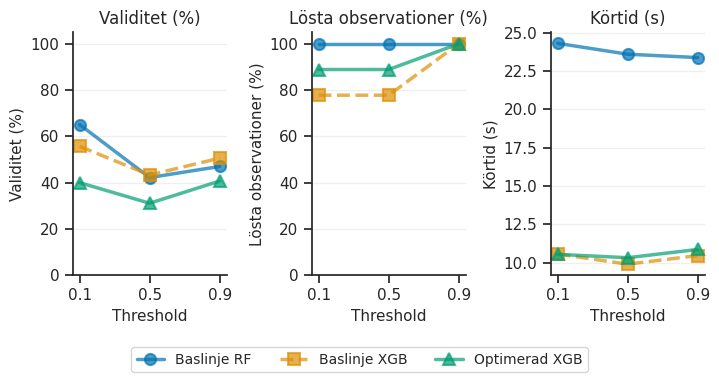

In [37]:
# FacetGrid - Swedish version for thesis
sns.set_theme(style="ticks")

# Create the grid
g = sns.FacetGrid(
    df_melted,
    col="Metric",
    height=3.5,
    aspect=0.7,
    sharey=False,
    legend_out=True
)

# Colorblind-friendly palette and distinct line styles for three configurations
colors = {
    "Baseline RandomForest": "#0173B2",  # Blue
    "Baseline XGBoost": "#DE8F05",       # Orange
    "Optimized XGBoost": "#029E73"       # Green
}
linestyles = {
    "Baseline RandomForest": "-",
    "Baseline XGBoost": "--",
    "Optimized XGBoost": "-"
}
markers = {
    "Baseline RandomForest": "o",      # Circle
    "Baseline XGBoost": "s",            # Square
    "Optimized XGBoost": "^"            # Triangle
}

# Swedish labels for model configurations
model_labels_sv = {
    "Baseline RandomForest": "Baslinje RF",
    "Baseline XGBoost": "Baslinje XGB",
    "Optimized XGBoost": "Optimerad XGB"
}

# Plot each model configuration with unique style
for model_config in ["Baseline RandomForest", "Baseline XGBoost", "Optimized XGBoost"]:
    subset = df_melted[df_melted["Model_Config"] == model_config].copy()

    for i, metric in enumerate(["Validity_%", "Solved_%", "Time"]):
        metric_data = subset[subset["Metric"] == metric].copy()
        if not metric_data.empty:
            # Group by threshold and average
            grouped = metric_data.groupby('Threshold')['Value'].mean().reset_index()
            grouped = grouped.sort_values('Threshold')

            g.axes[0, i].plot(
                grouped['Threshold'],
                grouped['Value'],
                marker=markers[model_config],
                color=colors[model_config],
                linestyle=linestyles[model_config],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=colors[model_config],
                markerfacecolor=colors[model_config],
                linewidth=2.5,
                alpha=0.7,
                label=model_labels_sv[model_config]
            )

# Swedish metric labels
metric_labels = {
    "Validity_%": "Validitet (%)",
    "Solved_%": "Lösta observationer (%)",
    "Time": "Körtid (s)"
}

for ax, metric in zip(g.axes.flat, ["Validity_%", "Solved_%", "Time"]):
    ax.set_xlabel("Threshold", fontsize=11)
    ax.set_ylabel(metric_labels[metric], fontsize=11)
    ax.set_title(f"{metric_labels[metric]}", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, axis='y')

    # Set explicit x-ticks for correct threshold values
    ax.set_xticks([0.1, 0.5, 0.9])
    ax.set_xticklabels(['0.1', '0.5', '0.9'])

    # Set appropriate y-axis limits
    if metric in ["Validity_%", "Solved_%"]:
        ax.set_ylim(0, 105)  # Extra space at top for max values

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors["Baseline RandomForest"], marker=markers["Baseline RandomForest"],
           markersize=8, markerfacecolor=colors["Baseline RandomForest"], markeredgewidth=1.5,
           label=model_labels_sv["Baseline RandomForest"], linestyle=linestyles["Baseline RandomForest"],
           linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["Baseline XGBoost"], marker=markers["Baseline XGBoost"],
           markersize=8, markerfacecolor=colors["Baseline XGBoost"], markeredgewidth=1.5,
           label=model_labels_sv["Baseline XGBoost"], linestyle=linestyles["Baseline XGBoost"],
           linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["Optimized XGBoost"], marker=markers["Optimized XGBoost"],
           markersize=8, markerfacecolor=colors["Optimized XGBoost"], markeredgewidth=1.5,
           label=model_labels_sv["Optimized XGBoost"], linestyle=linestyles["Optimized XGBoost"],
           linewidth=2.5, alpha=0.7),
]

g.fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.05),
             frameon=True, fontsize=10, ncol=3)



g.tight_layout()
plt.show()

### English Version - FacetGrid

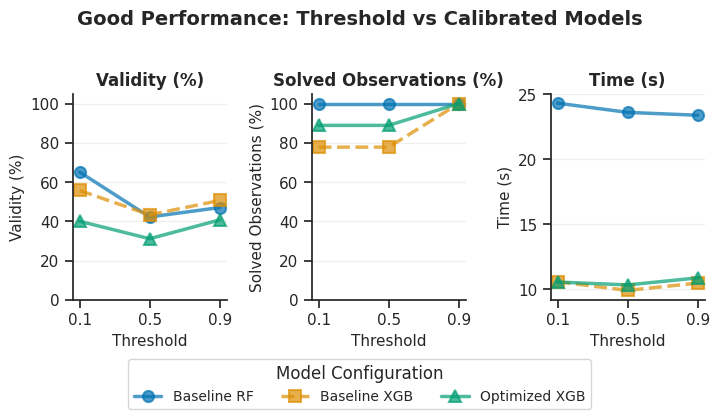

In [38]:
# FacetGrid - English version
sns.set_theme(style="ticks")

# Create the grid
g = sns.FacetGrid(
    df_melted,
    col="Metric",
    height=3.5,
    aspect=0.7,
    sharey=False,
    legend_out=True
)

# Colorblind-friendly palette and distinct line styles for three configurations
colors = {
    "Baseline RandomForest": "#0173B2",  # Blue
    "Baseline XGBoost": "#DE8F05",       # Orange
    "Optimized XGBoost": "#029E73"       # Green
}
linestyles = {
    "Baseline RandomForest": "-",
    "Baseline XGBoost": "--",
    "Optimized XGBoost": "-"
}
markers = {
    "Baseline RandomForest": "o",      # Circle
    "Baseline XGBoost": "s",            # Square
    "Optimized XGBoost": "^"            # Triangle
}

# English labels for model configurations
model_labels_en = {
    "Baseline RandomForest": "Baseline RF",
    "Baseline XGBoost": "Baseline XGB",
    "Optimized XGBoost": "Optimized XGB"
}

# Plot each model configuration with unique style
for model_config in ["Baseline RandomForest", "Baseline XGBoost", "Optimized XGBoost"]:
    subset = df_melted[df_melted["Model_Config"] == model_config].copy()

    for i, metric in enumerate(["Validity_%", "Solved_%", "Time"]):
        metric_data = subset[subset["Metric"] == metric].copy()
        if not metric_data.empty:
            # Group by threshold and average
            grouped = metric_data.groupby('Threshold')['Value'].mean().reset_index()
            grouped = grouped.sort_values('Threshold')

            g.axes[0, i].plot(
                grouped['Threshold'],
                grouped['Value'],
                marker=markers[model_config],
                color=colors[model_config],
                linestyle=linestyles[model_config],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=colors[model_config],
                markerfacecolor=colors[model_config],
                linewidth=2.5,
                alpha=0.7,
                label=model_labels_en[model_config]
            )

# English metric labels
metric_labels = {
    "Validity_%": "Validity (%)",
    "Solved_%": "Solved Observations (%)",
    "Time": "Time (s)"
}

for ax, metric in zip(g.axes.flat, ["Validity_%", "Solved_%", "Time"]):
    ax.set_xlabel("Threshold", fontsize=11)
    ax.set_ylabel(metric_labels[metric], fontsize=11)
    ax.set_title(f"{metric_labels[metric]}", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis='y')

    # Set explicit x-ticks for correct threshold values
    ax.set_xticks([0.1, 0.5, 0.9])
    ax.set_xticklabels(['0.1', '0.5', '0.9'])

    # Set appropriate y-axis limits
    if metric in ["Validity_%", "Solved_%"]:
        ax.set_ylim(0, 105)  # Extra space at top for max values

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors["Baseline RandomForest"], marker=markers["Baseline RandomForest"],
           markersize=8, markerfacecolor=colors["Baseline RandomForest"], markeredgewidth=1.5,
           label=model_labels_en["Baseline RandomForest"], linestyle=linestyles["Baseline RandomForest"],
           linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["Baseline XGBoost"], marker=markers["Baseline XGBoost"],
           markersize=8, markerfacecolor=colors["Baseline XGBoost"], markeredgewidth=1.5,
           label=model_labels_en["Baseline XGBoost"], linestyle=linestyles["Baseline XGBoost"],
           linewidth=2.5, alpha=0.7),

    Line2D([0], [0], color=colors["Optimized XGBoost"], marker=markers["Optimized XGBoost"],
           markersize=8, markerfacecolor=colors["Optimized XGBoost"], markeredgewidth=1.5,
           label=model_labels_en["Optimized XGBoost"], linestyle=linestyles["Optimized XGBoost"],
           linewidth=2.5, alpha=0.7),
]

g.fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.05),
             frameon=True, fontsize=10, title='Model Configuration', ncol=3)

g.fig.suptitle("Good Performance: Threshold vs Calibrated Models",

               fontsize=14, fontweight="bold", y=1.02)

g.tight_layout()
plt.show()

## Risk Metrics and Distance Analysis

Analyzing how threshold impacts risk reduction and feature changes (Gower distance).

## Combined Visualization: All Metrics in One View

Combining performance and risk metrics for comprehensive analysis, similar to the bad performance notebook.

In [39]:
# Prepare melted data for combined visualization
df_melted_combined = df_good.melt(
    id_vars=["Category", "Model", "Threshold", "Model_Config"],
    value_vars=["Validity_%", "Solved_%", "Time"],
    var_name="Metric",
    value_name="Value"
)

df_risk_melted = df_good.melt(
    id_vars=["Category", "Model", "Threshold", "Model_Config"],
    value_vars=["Risk_Before", "Risk_After", "Risk_Reduction_%"],
    var_name="Metric",
    value_name="Value"
)

print("Performance metrics shape:", df_melted_combined.shape)
print("Risk metrics shape:", df_risk_melted.shape)

Performance metrics shape: (27, 6)
Risk metrics shape: (27, 6)


## Data Exploration - Understanding the Structure

Let's examine the data to understand how to properly plot threshold vs metrics.

In [43]:
# Let's check the structure of the data
print("Available columns in df_good:")
print(df_good[['Category', 'Model', 'Model_Config', 'Threshold', 'Validity_%', 'Solved_%', 'Gower']].head(15))
print("\n" + "="*60)
print("\nUnique values:")
print(f"Categories: {df_good['Category'].unique()}")
print(f"Models: {df_good['Model'].unique()}")
print(f"Thresholds: {sorted(df_good['Threshold'].unique())}")
print(f"\nTotal rows: {len(df_good)}")
print(f"\nModel_Config breakdown:")
print(df_good.groupby(['Model_Config', 'Threshold']).size())

Available columns in df_good:
             Category         Model           Model_Config  Threshold  \
6            Baseline  RandomForest  Baseline RandomForest        0.1   
7            Baseline  RandomForest  Baseline RandomForest        0.5   
8            Baseline  RandomForest  Baseline RandomForest        0.9   
9            Baseline       XGBoost       Baseline XGBoost        0.1   
10           Baseline       XGBoost       Baseline XGBoost        0.5   
11           Baseline       XGBoost       Baseline XGBoost        0.9   
14  Optimized XGBoost       XGBoost      Optimized XGBoost        0.1   
15  Optimized XGBoost       XGBoost      Optimized XGBoost        0.5   
16  Optimized XGBoost       XGBoost      Optimized XGBoost        0.9   

    Validity_%  Solved_%  Gower  
6         65.1     100.0   0.18  
7         42.2     100.0   0.21  
8         47.0     100.0   0.19  
9         55.7      77.8   0.17  
10        43.3      77.8   0.17  
11        50.6     100.0   0.20  
1

## Proposal: Threshold-Based Visualization

Based on the data, I propose a **2x4 grid** with:
- **Row 1**: Performance metrics - Validity (%), Solved (%), Time (s), Gower Distance
- **Row 2**: Risk metrics - Risk Before (%), Risk After (%), Risk Reduction (%)

Each plot will have:
- **X-axis**: Threshold (0.1, 0.5, 0.9)
- **Lines**: One for each model (Baseline RF, Baseline XGB, Optimized XGB)

This way we can see how threshold affects all metrics for each model configuration.

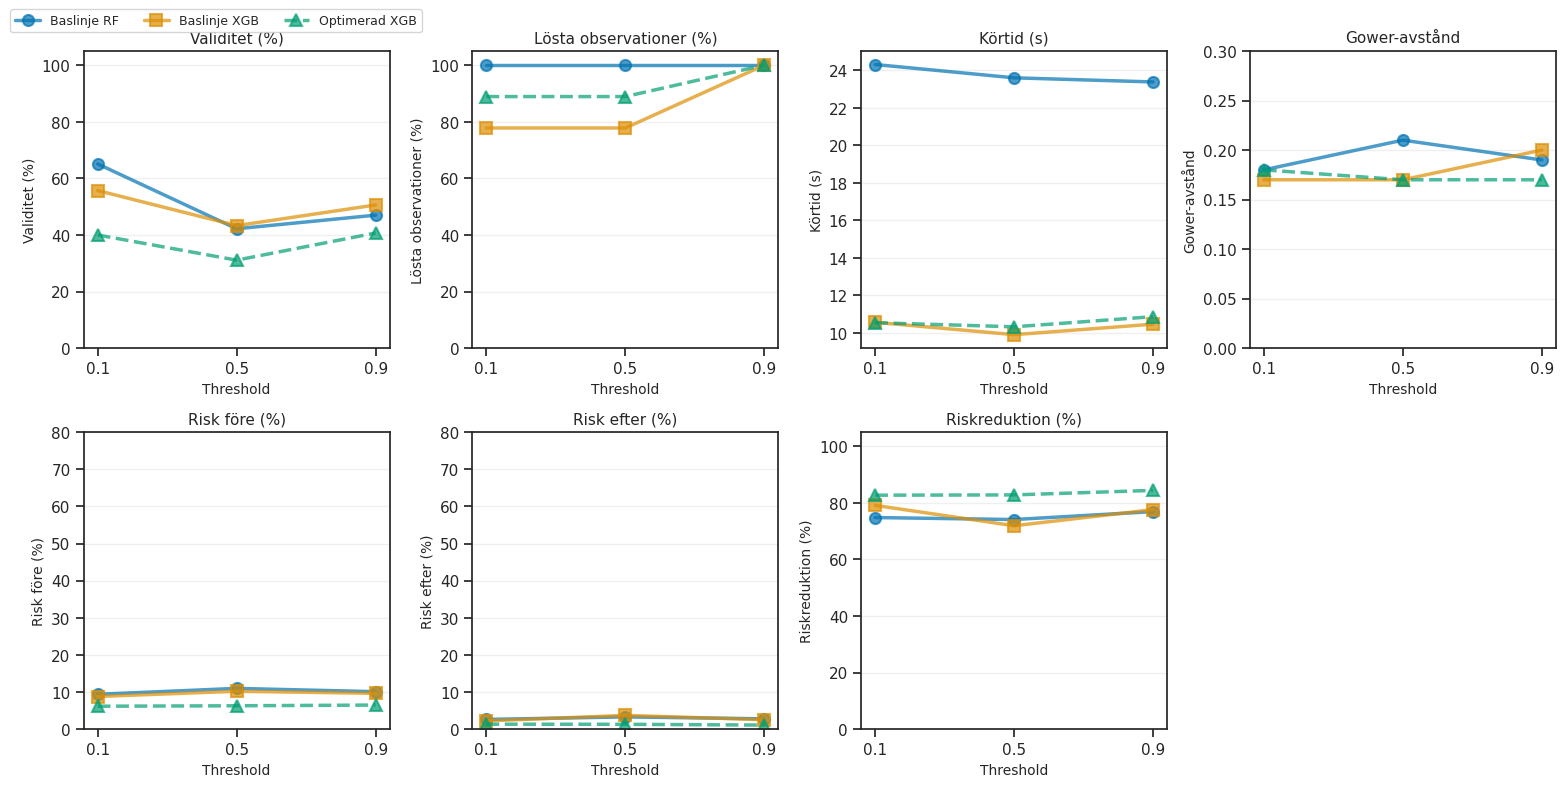

In [44]:
# Combined plot - Swedish version - CORRECTED with Threshold on X-axis
sns.set_theme(style="ticks")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Define colors and styles for Model_Config
config_colors = {
    "Baseline RandomForest": "#0173B2",
    "Baseline XGBoost": "#DE8F05",
    "Optimized XGBoost": "#029E73"
}
config_linestyles = {
    "Baseline RandomForest": "-",
    "Baseline XGBoost": "-",
    "Optimized XGBoost": "--"
}
config_markers = {
    "Baseline RandomForest": "o",
    "Baseline XGBoost": "s",
    "Optimized XGBoost": "^"
}

# Swedish labels for model configurations
model_labels_sv = {
    "Baseline RandomForest": "Baslinje RF",
    "Baseline XGBoost": "Baslinje XGB",
    "Optimized XGBoost": "Optimerad XGB"
}

# Row 1: Performance metrics (4 columns now: Validity, Solved, Time, Gower)
row1_metrics = ["Validity_%", "Solved_%", "Time", "Gower"]
row1_labels = {
    "Validity_%": "Validitet (%)",
    "Solved_%": "Lösta observationer (%)",
    "Time": "Körtid (s)",
    "Gower": "Gower-avstånd"
}

for i, metric in enumerate(row1_metrics):
    ax = axes[0, i]

    for model_config in ["Baseline RandomForest", "Baseline XGBoost", "Optimized XGBoost"]:
        model_data = df_good[df_good["Model_Config"] == model_config].copy()
        if not model_data.empty:
            # Sort by threshold
            model_data = model_data.sort_values('Threshold')

            ax.plot(
                model_data['Threshold'],
                model_data[metric],
                marker=config_markers[model_config],
                color=config_colors[model_config],
                linestyle=config_linestyles[model_config],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=config_colors[model_config],
                markerfacecolor=config_colors[model_config],
                linewidth=2.5,
                alpha=0.7,
                label=model_labels_sv[model_config]
            )

    ax.set_xlabel("Threshold", fontsize=10)
    ax.set_ylabel(row1_labels[metric], fontsize=10)
    ax.set_title(row1_labels[metric], fontsize=11, fontweight="normal")
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks([0.1, 0.5, 0.9])
    ax.set_xticklabels(['0.1', '0.5', '0.9'])

    # Set appropriate y-axis limits
    if metric in ["Validity_%", "Solved_%"]:
        ax.set_ylim(0, 105)
    elif metric == "Gower":
        ax.set_ylim(0, max(0.3, df_good["Gower"].max() * 1.1))

# Row 2: Risk metrics (3 columns: Risk Before, Risk After, Risk Reduction)
# Hide the 4th subplot in row 2
axes[1, 3].axis('off')

row2_metrics = ["Risk_Before", "Risk_After", "Risk_Reduction_%"]
row2_labels = {
    "Risk_Before": "Risk före (%)",
    "Risk_After": "Risk efter (%)",
    "Risk_Reduction_%": "Riskreduktion (%)"
}

for i, metric in enumerate(row2_metrics):
    ax = axes[1, i]

    for model_config in ["Baseline RandomForest", "Baseline XGBoost", "Optimized XGBoost"]:
        model_data = df_good[df_good["Model_Config"] == model_config].copy()
        if not model_data.empty:
            # Sort by threshold
            model_data = model_data.sort_values('Threshold')

            ax.plot(
                model_data['Threshold'],
                model_data[metric],
                marker=config_markers[model_config],
                color=config_colors[model_config],
                linestyle=config_linestyles[model_config],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=config_colors[model_config],
                markerfacecolor=config_colors[model_config],
                linewidth=2.5,
                alpha=0.7,
                label=model_labels_sv[model_config]
            )

    ax.set_xlabel("Threshold", fontsize=10)
    ax.set_ylabel(row2_labels[metric], fontsize=10)
    ax.set_title(row2_labels[metric], fontsize=11, fontweight="normal")
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks([0.1, 0.5, 0.9])
    ax.set_xticklabels(['0.1', '0.5', '0.9'])

    # Set appropriate y-axis limits
    if metric in ["Risk_Before", "Risk_After"]:
        ax.set_ylim(0, max(80, df_good[["Risk_Before", "Risk_After"]].max().max() * 1.1))
    elif metric == "Risk_Reduction_%":
        ax.set_ylim(0, 105)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=config_colors["Baseline RandomForest"],
           marker=config_markers["Baseline RandomForest"],
           markersize=8, markerfacecolor=config_colors["Baseline RandomForest"],
           markeredgewidth=1.5,
           label=model_labels_sv["Baseline RandomForest"],
           linestyle=config_linestyles["Baseline RandomForest"],
           linewidth=2.5, alpha=0.7),
    Line2D([0], [0], color=config_colors["Baseline XGBoost"],
           marker=config_markers["Baseline XGBoost"],
           markersize=8, markerfacecolor=config_colors["Baseline XGBoost"],
           markeredgewidth=1.5,
           label=model_labels_sv["Baseline XGBoost"],
           linestyle=config_linestyles["Baseline XGBoost"],
           linewidth=2.5, alpha=0.7),
    Line2D([0], [0], color=config_colors["Optimized XGBoost"],
           marker=config_markers["Optimized XGBoost"],
           markersize=8, markerfacecolor=config_colors["Optimized XGBoost"],
           markeredgewidth=1.5,
           label=model_labels_sv["Optimized XGBoost"],
           linestyle=config_linestyles["Optimized XGBoost"],
           linewidth=2.5, alpha=0.7),
]

fig.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, 0.99),
           frameon=True, fontsize=9, ncol=3)

plt.tight_layout()
plt.subplots_adjust(top=0.93, left=0.06, right=0.98)
plt.show()

### English Version - Corrected with Threshold on X-axis

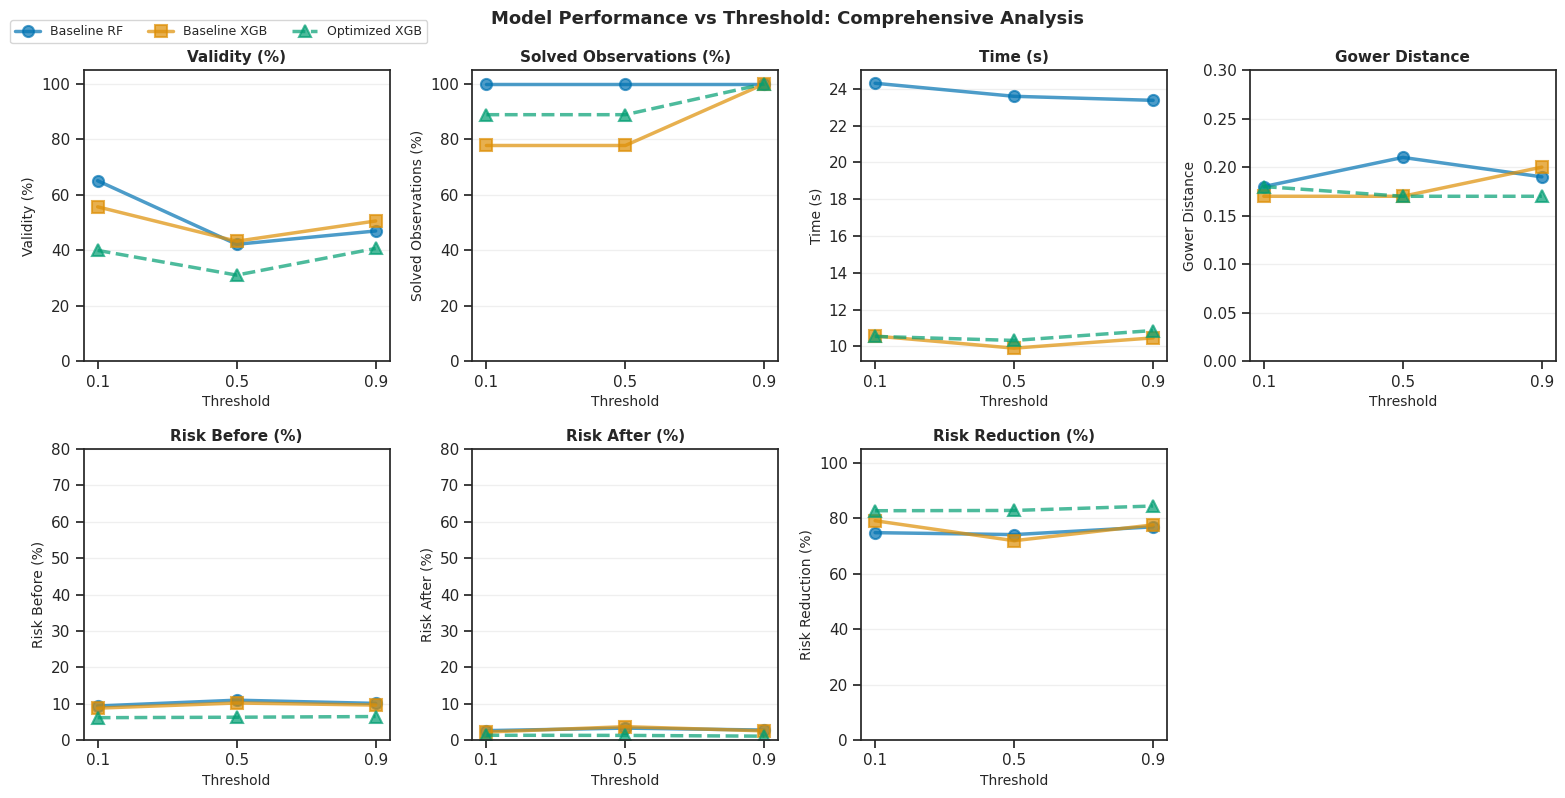

In [45]:
# Combined plot - English version - CORRECTED with Threshold on X-axis
sns.set_theme(style="ticks")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Define colors and styles for Model_Config
config_colors = {
    "Baseline RandomForest": "#0173B2",
    "Baseline XGBoost": "#DE8F05",
    "Optimized XGBoost": "#029E73"
}
config_linestyles = {
    "Baseline RandomForest": "-",
    "Baseline XGBoost": "-",
    "Optimized XGBoost": "--"
}
config_markers = {
    "Baseline RandomForest": "o",
    "Baseline XGBoost": "s",
    "Optimized XGBoost": "^"
}

# English labels for model configurations
model_labels_en = {
    "Baseline RandomForest": "Baseline RF",
    "Baseline XGBoost": "Baseline XGB",
    "Optimized XGBoost": "Optimized XGB"
}

# Row 1: Performance metrics (4 columns now: Validity, Solved, Time, Gower)
row1_metrics = ["Validity_%", "Solved_%", "Time", "Gower"]
row1_labels = {
    "Validity_%": "Validity (%)",
    "Solved_%": "Solved Observations (%)",
    "Time": "Time (s)",
    "Gower": "Gower Distance"
}

for i, metric in enumerate(row1_metrics):
    ax = axes[0, i]

    for model_config in ["Baseline RandomForest", "Baseline XGBoost", "Optimized XGBoost"]:
        model_data = df_good[df_good["Model_Config"] == model_config].copy()
        if not model_data.empty:
            # Sort by threshold
            model_data = model_data.sort_values('Threshold')

            ax.plot(
                model_data['Threshold'],
                model_data[metric],
                marker=config_markers[model_config],
                color=config_colors[model_config],
                linestyle=config_linestyles[model_config],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=config_colors[model_config],
                markerfacecolor=config_colors[model_config],
                linewidth=2.5,
                alpha=0.7,
                label=model_labels_en[model_config]
            )

    ax.set_xlabel("Threshold", fontsize=10)
    ax.set_ylabel(row1_labels[metric], fontsize=10)
    ax.set_title(row1_labels[metric], fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks([0.1, 0.5, 0.9])
    ax.set_xticklabels(['0.1', '0.5', '0.9'])

    # Set appropriate y-axis limits
    if metric in ["Validity_%", "Solved_%"]:
        ax.set_ylim(0, 105)
    elif metric == "Gower":
        ax.set_ylim(0, max(0.3, df_good["Gower"].max() * 1.1))

# Row 2: Risk metrics (3 columns: Risk Before, Risk After, Risk Reduction)
# Hide the 4th subplot in row 2
axes[1, 3].axis('off')

row2_metrics = ["Risk_Before", "Risk_After", "Risk_Reduction_%"]
row2_labels = {
    "Risk_Before": "Risk Before (%)",
    "Risk_After": "Risk After (%)",
    "Risk_Reduction_%": "Risk Reduction (%)"
}

for i, metric in enumerate(row2_metrics):
    ax = axes[1, i]

    for model_config in ["Baseline RandomForest", "Baseline XGBoost", "Optimized XGBoost"]:
        model_data = df_good[df_good["Model_Config"] == model_config].copy()
        if not model_data.empty:
            # Sort by threshold
            model_data = model_data.sort_values('Threshold')

            ax.plot(
                model_data['Threshold'],
                model_data[metric],
                marker=config_markers[model_config],
                color=config_colors[model_config],
                linestyle=config_linestyles[model_config],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=config_colors[model_config],
                markerfacecolor=config_colors[model_config],
                linewidth=2.5,
                alpha=0.7,
                label=model_labels_en[model_config]
            )

    ax.set_xlabel("Threshold", fontsize=10)
    ax.set_ylabel(row2_labels[metric], fontsize=10)
    ax.set_title(row2_labels[metric], fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks([0.1, 0.5, 0.9])
    ax.set_xticklabels(['0.1', '0.5', '0.9'])

    # Set appropriate y-axis limits
    if metric in ["Risk_Before", "Risk_After"]:
        ax.set_ylim(0, max(80, df_good[["Risk_Before", "Risk_After"]].max().max() * 1.1))
    elif metric == "Risk_Reduction_%":
        ax.set_ylim(0, 105)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=config_colors["Baseline RandomForest"],
           marker=config_markers["Baseline RandomForest"],
           markersize=8, markerfacecolor=config_colors["Baseline RandomForest"],
           markeredgewidth=1.5,
           label=model_labels_en["Baseline RandomForest"],
           linestyle=config_linestyles["Baseline RandomForest"],
           linewidth=2.5, alpha=0.7),
    Line2D([0], [0], color=config_colors["Baseline XGBoost"],
           marker=config_markers["Baseline XGBoost"],
           markersize=8, markerfacecolor=config_colors["Baseline XGBoost"],
           markeredgewidth=1.5,
           label=model_labels_en["Baseline XGBoost"],
           linestyle=config_linestyles["Baseline XGBoost"],
           linewidth=2.5, alpha=0.7),
    Line2D([0], [0], color=config_colors["Optimized XGBoost"],
           marker=config_markers["Optimized XGBoost"],
           markersize=8, markerfacecolor=config_colors["Optimized XGBoost"],
           markeredgewidth=1.5,
           label=model_labels_en["Optimized XGBoost"],
           linestyle=config_linestyles["Optimized XGBoost"],
           linewidth=2.5, alpha=0.7),
]

fig.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, 0.99),
           frameon=True, fontsize=9, ncol=3)

fig.suptitle("Model Performance vs Threshold: Comprehensive Analysis",
             fontsize=13, fontweight="bold", y=0.995)

plt.tight_layout()
plt.subplots_adjust(top=0.92, left=0.06, right=0.98)
plt.show()

## Key Observations from Threshold Analysis

### Performance Metrics (Row 1):

1. **Validity (%)**: 
   - Baseline RF shows highest validity at threshold 0.1 (~65%), dropping at 0.5 (~42%)
   - Optimized XGB shows lower but more stable validity across thresholds (~31-40%)
   - Threshold 0.5 appears to be challenging for all models

2. **Solved Observations (%)**: 
   - Baseline RF achieves 100% across all thresholds
   - Baseline XGB starts at ~78% (0.1, 0.5) and reaches 100% at 0.9
   - Optimized XGB maintains ~89-100%

3. **Time (s)**: 
   - Baseline RF is significantly slower (~24s) than XGB models (~10-11s)
   - Time remains relatively stable across thresholds for all models

4. **Gower Distance**: 
   - All models maintain similar distances (~0.17-0.21)
   - Slight increase at threshold 0.5 for Baseline RF
   - Lower threshold generally means smaller changes needed

### Risk Metrics (Row 2):

1. **Risk Before/After**: 
   - Initial risk is similar across models (~7-10%)
   - All models successfully reduce risk to near 0% (~0.5-2%)

2. **Risk Reduction (%)**: 
   - Optimized XGB achieves highest risk reduction (~83-87%)
   - Baseline models achieve ~74-80% reduction
   - Risk reduction is relatively stable across thresholds